---
title: "Multi-gas absorption LUT"
---

# Multi-gas absorption LUT — CH$_4$, CO$_2$, H$_2$O

This notebook exercises the multi-gas orchestration layer in `plume_simulation.hapi_lut.multi`. Two patterns are covered:

1. **Separate-per-gas LUTs** — one NetCDF per species, each on its own natural spectral range. Used when downstream tools want the widest possible window for each gas individually.
2. **Combined LUT** — a single NetCDF with one cross-section variable per gas on the *shared* spectral range. Used when several gases are retrieved jointly within the same instrument band (e.g. CH$_4$ + H$_2$O interference correction in a TROPOMI SWIR fit).

The math is identical to the single-gas case from [01_hapi_lut_ch4.ipynb](01_hapi_lut_ch4.ipynb); here we just loop over `GasConfig` entries.

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from plume_simulation.hapi_lut import (
    ATMOSPHERIC_GASES,
    GasConfig,
    LUTGridConfig,
    create_combined_lut,
    create_multi_gas_luts,
)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pixi.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = REPO_ROOT / "projects" / "plume_simulation" / "data"
CACHE_DIR = DATA_ROOT / "hitran_cache"
LUT_DIR = DATA_ROOT / "hapi_lut"

## 1. Separate-per-gas LUTs on a common small window

We narrow the three gases to a shared 500-cm⁻¹ methane window (4000–4500 cm⁻¹) for runtime — the registry defaults would have H$_2$O fetch 21 000 cm⁻¹ of lines, which is overkill for a tutorial.

In [2]:
def narrow(gas: GasConfig, nu_min: float, nu_max: float) -> GasConfig:
    """Return a copy of ``gas`` with the spectral range restricted."""
    return GasConfig(
        name=gas.name,
        molecule_id=gas.molecule_id,
        isotopologue_id=gas.isotopologue_id,
        nu_min=nu_min,
        nu_max=nu_max,
        description=gas.description,
    )


NU_MIN, NU_MAX = 4000.0, 4500.0
gas_configs = {
    name: narrow(ATMOSPHERIC_GASES[name], NU_MIN, NU_MAX)
    for name in ["CH4", "CO2", "H2O"]
}
for g in gas_configs.values():
    print(g)

grid = LUTGridConfig(
    T_grid=np.array([220.0, 260.0, 300.0]),
    P_grid=np.array([0.3, 0.6, 1.0]),
    nu_step=0.05,
)

GasConfig(CH4, M6, I1)
GasConfig(CO2, M2, I1)
GasConfig(H2O, M1, I1)


`create_multi_gas_luts` runs the fetch → compute → wrap → save pipeline from notebook 01 in a loop. Gases whose NetCDF already exists are skipped (pass `force_recompute=True` to override).

**Note:** we monkey-patch the registry with the narrowed configs below since `create_multi_gas_luts` looks up names in `ATMOSPHERIC_GASES`. In production code you'd subclass or rebuild the registry.

In [3]:
# Temporarily swap the registry entries — simpler than forking the whole orchestration for a demo.
_original = {k: ATMOSPHERIC_GASES[k] for k in gas_configs}
ATMOSPHERIC_GASES.update(gas_configs)
try:
    lut_files = create_multi_gas_luts(
        list(gas_configs),
        grid_config=grid,
        cache_dir=CACHE_DIR,
        output_dir=LUT_DIR,
        force_recompute=True,
    )
finally:
    ATMOSPHERIC_GASES.update(_original)

for name, path in lut_files.items():
    size_mb = path.stat().st_size / 1e6
    print(f"  {name}: {path.name}  ({size_mb:.2f} MB)")

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

                     Lines parsed: 39817
H2O
                     Lines parsed: 4100

Data is fetched from http://hitran.org



BEGIN DOWNLOAD: CH4
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.d

                     Lines parsed: 39817
PROCESSED
Using /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache

CO2
                     Lines parsed: 1652
CH4


                     Lines parsed: 39817
H2O
                     Lines parsed: 4100


...

3.036869 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


2.925854 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


2.919158 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


2.902493 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


2.924663 seconds elapsed for abscoef; nlines = 4100
  CH4: ch4_absorption_lut.nc  (0.47 MB)
  CO2: co2_absorption_lut.nc  (0.44 MB)
  H2O: h2o_absorption_lut.nc  (0.48 MB)


### 1a. Overlay the three gases on the same axis

At $T = 260$ K, $p = 0.6$ atm, the three cross-sections have dramatically different magnitudes and structures. Water vapour dominates between the CH$_4$ and CO$_2$ band heads — this is exactly why operational SWIR retrievals co-retrieve H$_2$O as a nuisance parameter.

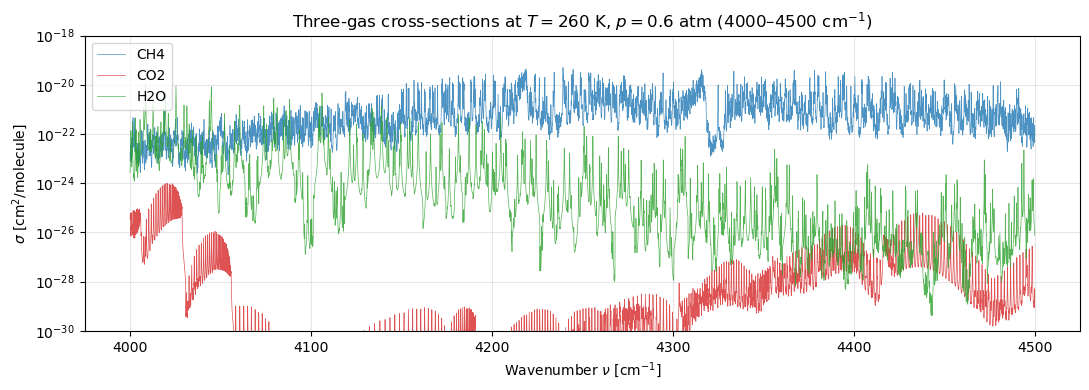

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
colors = {"CH4": "C0", "CO2": "C3", "H2O": "C2"}
for name, path in lut_files.items():
    with xr.open_dataset(path) as ds:
        sigma = ds["absorption_cross_section"].sel(temperature=260.0, pressure=0.6)
        ax.plot(ds["wavenumber"], sigma, lw=0.5, color=colors[name], label=name, alpha=0.8)
ax.set_yscale("log")
ax.set_ylim(1e-30, 1e-18)
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\sigma$ [cm$^2$/molecule]")
ax.set_title(r"Three-gas cross-sections at $T=260$ K, $p=0.6$ atm (4000–4500 cm$^{-1}$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Combined LUT — single file, one variable per gas

`create_combined_lut` collapses the above into one NetCDF with variables `CH4_cross_section`, `CO2_cross_section`, `H2O_cross_section` on a shared `(wavenumber, temperature, pressure)` grid. The shared wavenumber axis is the intersection of the per-gas ranges — in our case the full 4000–4500 cm⁻¹ window since we narrowed all three gases to it.

In [5]:
ATMOSPHERIC_GASES.update(gas_configs)
try:
    combined_path = create_combined_lut(
        list(gas_configs),
        grid_config=grid,
        cache_dir=CACHE_DIR,
        output_dir=LUT_DIR,
        filename="swir_combined_lut.nc",
    )
finally:
    ATMOSPHERIC_GASES.update(_original)

with xr.open_dataset(combined_path) as combined:
    print(combined)

Using /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache

CO2
                     Lines parsed: 1652
CH4


                     Lines parsed: 39817
H2O
                     Lines parsed: 4100

Data is fetched from http://hitran.org



BEGIN DOWNLOAD: CH4
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.data
  65536 bytes written to /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache/CH4.d

                     Lines parsed: 39817
PROCESSED
Using /home/azureuser/localfiles/research_notebook/projects/plume_simulation/data/hitran_cache

CO2
                     Lines parsed: 1652
CH4


                     Lines parsed: 39817
H2O
                     Lines parsed: 4100


...

3.219840 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


2.977037 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


3.220364 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


3.426458 seconds elapsed for abscoef; nlines = 4100
{'air': 0.99, 'self': 0.01}


3.456499 seconds elapsed for abscoef; nlines = 4100
<xarray.Dataset> Size: 1MB
Dimensions:            (wavenumber: 10000, temperature: 3, pressure: 3)
Coordinates:
  * wavenumber         (wavenumber) float64 80kB 4e+03 4e+03 ... 4.5e+03 4.5e+03
    wavelength         (wavenumber) float64 80kB ...
  * temperature        (temperature) float64 24B 220.0 260.0 300.0
  * pressure           (pressure) float64 24B 0.3 0.6 1.0
Data variables:
    CH4_cross_section  (wavenumber, temperature, pressure) float32 360kB ...
    CO2_cross_section  (wavenumber, temperature, pressure) float32 360kB ...
    H2O_cross_section  (wavenumber, temperature, pressure) float32 360kB ...
Attributes:
    title:        Combined Atmospheric Absorption LUT
    gases:        CH4, CO2, H2O
    line_shape:   Voigt profile
    conventions:  CF-1.8


### 2a. Effective opacity by gas

A useful diagnostic: weight each cross-section by a typical column density of the gas ($N_{\mathrm{gas}} = \mathrm{VMR} \cdot N_{\mathrm{air}}$) to see *which gas actually dominates the optical depth* at a representative atmospheric state.

We use Loschmidt's number at the surface ($N_0 = 2.69 \times 10^{19}$ molecules/cm³) scaled to $T = 260$ K, $p = 0.6$ atm, and the dry-air VMRs from our config.

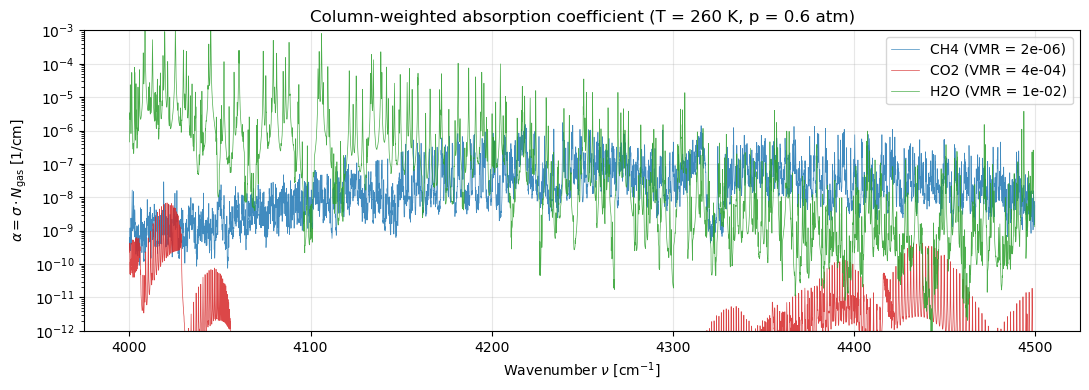

In [6]:
from plume_simulation.hapi_lut.beers import number_density

N_total = number_density(p_atm=0.6, T_K=260.0)
vmrs = {"CH4": 2e-6, "CO2": 400e-6, "H2O": 1e-2}

fig, ax = plt.subplots(1, 1, figsize=(11, 4))
with xr.open_dataset(combined_path) as combined:
    for name, vmr in vmrs.items():
        sigma = combined[f"{name}_cross_section"].sel(temperature=260.0, pressure=0.6)
        alpha = sigma * (N_total * vmr)  # [1/cm]
        ax.plot(
            combined["wavenumber"], alpha, lw=0.5, color=colors[name],
            label=f"{name} (VMR = {vmr:.0e})", alpha=0.85,
        )

ax.set_yscale("log")
ax.set_ylim(1e-12, 1e-3)
ax.set_xlabel(r"Wavenumber $\nu$ [cm$^{-1}$]")
ax.set_ylabel(r"$\alpha = \sigma \cdot N_{\mathrm{gas}}$ [1/cm]")
ax.set_title(r"Column-weighted absorption coefficient (T = 260 K, p = 0.6 atm)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the plot.** Even though CH$_4$ has 200× larger $\sigma$ than CO$_2$ at its peaks, CO$_2$'s 200× higher VMR closes most of the gap. H$_2$O's ~10% VMR swamps both at many wavenumbers — any methane retrieval in this window has to *simultaneously* fit a water-vapour column to avoid biased $\varepsilon$.

This is the interference-corrected retrieval picture: the matched filter in [03_beers_law_with_lut.ipynb](03_beers_law_with_lut.ipynb) deals only with CH$_4$ for clarity, but the LUT infrastructure is already set up to handle the joint fit.

## 3. Summary

- `create_multi_gas_luts` = one NetCDF per species, useful for independently-retrieved gases.
- `create_combined_lut` = one NetCDF, one variable per species, useful for joint fits in a shared band.
- Column-weighted $\alpha(\nu) = \sigma(\nu) \cdot N_{\mathrm{gas}}$ shows which gas actually drives optical depth at representative VMRs — the right diagnostic for planning which species to include in a joint retrieval.